<a href="https://colab.research.google.com/github/true-cpu/ThucHanhDeepLearning/blob/main/buoi3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# 1. Giải nén dữ liệu
zip_file_path = '/content/archive.zip'
extract_dir = '/content/extracted_data'
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# 2. Tải dữ liệu
df = pd.read_csv(os.path.join(extract_dir, 'data.csv'))
print("Dữ liệu đã được tải thành công.")
display(df.head())

Dữ liệu đã được tải thành công.


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [91]:
# 3. Tiền xử lý dữ liệu
# Loại bỏ cột không cần thiết
df = df.drop(['country', 'street'], axis=1)

# Xử lý cột ngày tháng
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df = df.sort_values('date').drop('date', axis=1)

# Mã hóa One-hot cho cột City
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
city_encoded = encoder.fit_transform(df[['city', 'statezip']])
city_df = pd.DataFrame(city_encoded, columns=encoder.get_feature_names_out(['city', 'statezip']), index=df.index)
df = pd.concat([df.drop(['city', 'statezip'], axis=1), city_df], axis=1)

# Chuẩn hóa dữ liệu
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X = df.drop('price', axis=1)
y = df['price'].values.reshape(-1, 1)

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Chia dữ liệu (70% train, 30% val)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, shuffle=False)

# Định dạng lại cho LSTM [samples, time_steps, features]
X_train_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val_rnn = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])

print(f"Tiền xử lý hoàn tất. Hình dạng đầu vào: {X_train_rnn.shape}")

Tiền xử lý hoàn tất. Hình dạng đầu vào: (3220, 1, 136)


In [92]:
# Hiển thị thống kê mô tả cho các cột số
display(df.describe())

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,...,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,...,0.019130,0.012826,0.014565,0.011522,0.010652,0.005000,0.012174,0.014783,0.000652,0.000435
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,...,0.136998,0.112536,0.119817,0.106731,0.102669,0.070541,0.109674,0.120695,0.025532,0.020849
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [93]:
# Loại bỏ các cột one-hot encoded quá thưa thớt
# Đếm số lượng giá trị 1 trong mỗi cột one-hot encoded
# Xác định các cột one-hot encoded (tất cả các cột trừ các cột số gốc và `price`)
one_hot_cols = [col for col in df.columns if col.startswith(('city_', 'statezip_'))]

# Tính tổng số lượng '1' trong mỗi cột one-hot
counts = df[one_hot_cols].sum()

# Xác định ngưỡng. Ví dụ: loại bỏ các cột có ít hơn 10 lần xuất hiện của giá trị 1
sparse_cols = counts[counts < 10].index.tolist()

print(f"Số lượng cột one-hot encoded ban đầu: {len(one_hot_cols)}")
print(f"Số lượng cột one-hot encoded sẽ bị loại bỏ do quá thưa thớt: {len(sparse_cols)}")

# Loại bỏ các cột thưa thớt khỏi DataFrame
df = df.drop(columns=sparse_cols)

print(f"Số lượng cột sau khi loại bỏ các cột thưa thớt: {df.shape[1]}")

# Cập nhật lại các bước tiền xử lý sau khi loại bỏ cột
# Tách X và y
X = df.drop('price', axis=1)
y = df['price'].values.reshape(-1, 1)

# Chuẩn hóa dữ liệu với scaler đã được khởi tạo trước đó
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Chia dữ liệu (70% train, 30% val)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, shuffle=False)

# Định dạng lại cho LSTM [samples, time_steps, features]
X_train_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val_rnn = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])

print(f"Tiền xử lý hoàn tất sau khi loại bỏ cột thưa thớt. Hình dạng đầu vào mới: {X_train_rnn.shape}")

Số lượng cột one-hot encoded ban đầu: 121
Số lượng cột one-hot encoded sẽ bị loại bỏ do quá thưa thớt: 18
Số lượng cột sau khi loại bỏ các cột thưa thớt: 119
Tiền xử lý hoàn tất sau khi loại bỏ cột thưa thớt. Hình dạng đầu vào mới: (3220, 1, 118)


### 3.2. Xử lý Outlier trong các biến số

Sau khi loại bỏ các cột one-hot thưa thớt, chúng ta cần xem xét các cột số có thể có outlier (giá trị ngoại lai) làm ảnh hưởng đến hiệu suất của mô hình. Mặc dù Min-Max Scaling đã chuẩn hóa các giá trị về một phạm vi nhất định, nhưng các outlier vẫn có thể kéo giãn phạm vi đó và làm giảm hiệu quả của quá trình huấn luyện.

Chúng ta sẽ sử dụng phương pháp Interquartile Range (IQR) để phát hiện và giới hạn (cap) các outlier trong các cột số chính (`price`, `sqft_living`, `sqft_lot`, `sqft_above`). Điều này giúp làm giảm ảnh hưởng của các giá trị cực đoan mà không loại bỏ hoàn toàn các điểm dữ liệu.


In [94]:
# Xác định các cột số cần xử lý outlier
numerical_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'year', 'month', 'day']

# Chỉ lấy các cột số thực sự tồn tại trong DataFrame
numerical_cols_present = [col for col in numerical_cols if col in df.columns]

print(f"Các cột số sẽ được xử lý outlier: {numerical_cols_present}")

# Áp dụng capping outlier cho các cột số
for col in numerical_cols_present:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    # Capping outliers
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

print("Đã xử lý outlier cho các cột số.")

# Cập nhật lại các bước tiền xử lý sau khi xử lý outlier
# Tách X và y
X = df.drop('price', axis=1)
y = df['price'].values.reshape(-1, 1)

# Chuẩn hóa dữ liệu với scaler đã được khởi tạo trước đó
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Chia dữ liệu (70% train, 30% val)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, shuffle=False)

# Định dạng lại cho LSTM [samples, time_steps, features]
X_train_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val_rnn = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])

print(f"Tiền xử lý hoàn tất sau khi xử lý outlier. Hình dạng đầu vào mới: {X_train_rnn.shape}")

Các cột số sẽ được xử lý outlier: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'year', 'month', 'day']
Đã xử lý outlier cho các cột số.
Tiền xử lý hoàn tất sau khi xử lý outlier. Hình dạng đầu vào mới: (3220, 1, 118)


In [95]:
# 4. Tinh chỉnh mô hình RNN (Sử dụng tanh và batch size nhỏ hơn)
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Sử dụng Adam với learning rate tiêu chuẩn
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_rnn, y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val_rnn, y_val),
    verbose=1
)
print("Huấn luyện mô hình tinh chỉnh hoàn tất.")

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


202/202 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0449 - mae: 0.1478 - val_loss: 0.0169 - val_mae: 0.0851
Epoch 2/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0175 - mae: 0.0900 - val_loss: 0.0152 - val_mae: 0.0774
Epoch 3/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0167 - mae: 0.0852 - val_loss: 0.0154 - val_mae: 0.0772
Epoch 4/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0158 - mae: 0.0824 - val_loss: 0.0144 - val_mae: 0.0740
Epoch 5/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0156 - mae: 0.0822 - val_loss: 0.0162 - val_mae: 0.0809
Epoch 6/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0153 - mae: 0.0809 - val_loss: 0.0140 - val_mae: 0.0724
Epoch 7/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0148 - mae: 0.0785 - val_loss: 0.0165 - val_mae: 0.0838
Epoch 8/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0147 - mae: 0.0792 - val_loss: 0.0145 - val_mae: 0.0747
Epoch 9/200
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

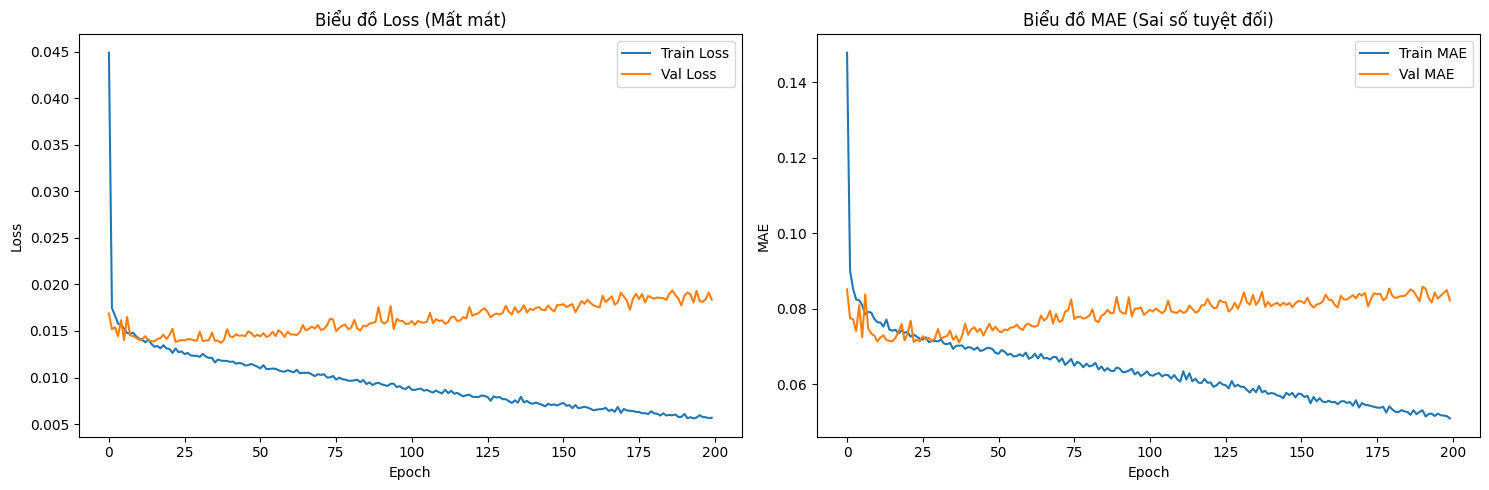

In [96]:
# Vẽ biểu đồ Loss và MAE (thay thế cho Accuracy vì đây là bài toán hồi quy)
plt.figure(figsize=(15, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Biểu đồ Loss (Mất mát)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Biểu đồ MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Biểu đồ MAE (Sai số tuyệt đối)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


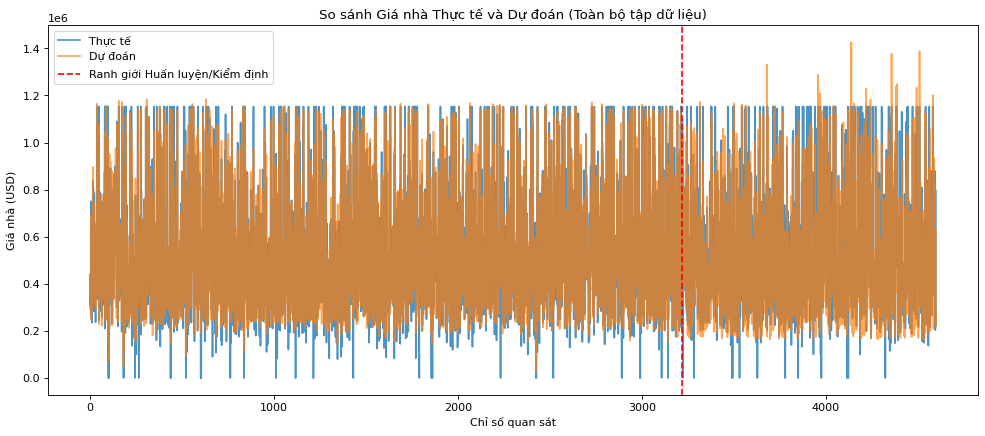

In [97]:
def plot_result(trainY, testY, train_predict, test_predict):
    # Chuyển đổi về thang đo gốc nếu cần (ở đây đã thực hiện trước khi gọi hàm)
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual, label='Thực tế', alpha=0.8)
    plt.plot(range(rows), predictions, label='Dự đoán', alpha=0.7)
    plt.axvline(x=len(trainY), color='r', linestyle='--', label='Ranh giới Huấn luyện/Kiểm định')

    plt.legend()
    plt.xlabel('Chỉ số quan sát')
    plt.ylabel('Giá nhà (USD)')
    plt.title('So sánh Giá nhà Thực tế và Dự đoán (Toàn bộ tập dữ liệu)')
    plt.show()

# Chuẩn bị dữ liệu dự đoán trên tập huấn luyện để vẽ biểu đồ tổng thể
y_train_pred_scaled = model.predict(X_train_rnn)
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_train_true = scaler_y.inverse_transform(y_train)

# Gọi hàm vẽ biểu đồ
plot_result(y_train_true, y_true, y_train_pred, y_pred)

In [98]:
# 5. Đánh giá và Lập bảng kết quả cập nhật
y_pred_scaled = model.predict(X_val_rnn)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_val)

r2 = r2_score(y_true, y_pred)
mae_val = np.mean(np.abs(y_true - y_pred))

def classify(r2_score):
    if r2_score > 0.8: return "Tốt"
    if r2_score > 0.5: return "Khá"
    if r2_score > 0.1: return "Trung bình"
    return "Tệ"

eval_table = pd.DataFrame({
    'Tiêu chí': ['Độ phù hợp (R-squared)', 'Sai lệch trung bình', 'Xếp loại chất lượng'],
    'Kết quả': [f"{r2*100:.2f}%", f"{mae_val:,.2f} USD", classify(r2)]
})

display(eval_table)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,Tiêu chí,Kết quả
0,Độ phù hợp (R-squared),65.47%
1,Sai lệch trung bình,"94,754.18 USD"
2,Xếp loại chất lượng,Khá
